In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays
using StatsBase
using CairoMakie
using LaTeXStrings

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Determine eq and threshold

In [4]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

# vel = [10.0]
vel = [5.0, 10.0, 20.0, 100.0]
tms = [1.0]
steps = 120000

for (idx_v, v) in enumerate(vel)
    for (idx_t, tm) in enumerate(tms)
        rows = 4
        cols = 4
        fig2 = Figure(size=(900 * cols, 600 * rows))

        for (idx, lambda) in enumerate(lambdas)
        
            filename = @sprintf("fsb_tm_%s_v_%s_n_%s.jld2", tm, v, lambda)
            
            row = ceil(Int, idx / cols)
            col = (idx - 1) % cols + 1
            
            ax = Axis(fig2[row, col], 
                    xlabel="Time (s)", 
                    ylabel="Distance to source (X)",
                    title="Λ = $lambda")

            jldopen(filename, "r") do file 
                for agent in 1:100
                    mean_dist_x = Float64[] 
                    for step in 100:100:steps
            
                        g = file[@sprintf("step_%06d", step)]

                        other_x = g["x"][agent]
                        dists_x = other_x .- 0

                        push!(mean_dist_x, mean(dists_x))
        
                    end

                    # Plotting X data
                    lines!(ax, (100:100:steps)*0.01, mean_dist_x, label="Mean X")
                end
            end
        end
        save("Plots/Fixed_source_model/Next/All/Trajectories_tm$(tm)_v$(v).pdf", fig2)
    end
end

# Load dc and delta, threshold and eq time

In [5]:
df_times = CSV.read("df_times_all.csv", DataFrame)

Row,tm,n,v,Dc,delta,l,Lambda,eq,threshold
,Int64,String7,Int64,String15,String15,String15,String15,Int64,Int64
1,1,"0,25",10,40,"0,0025","126,4911064","0,0790569415",50000,100
2,1,"0,5",10,20,"0,005","63,2455532","0,158113883",50000,75
3,1,"0,75",10,"13,33333333","0,0075","42,16370214","0,2371708245",50000,75
4,1,1,10,10,"0,01","31,6227766","0,316227766",50000,75
5,1,2,10,5,"0,02","15,8113883","0,632455532",50000,50
6,1,3,10,"3,333333333","0,03","10,54092553","0,9486832981",50000,50
7,1,4,10,"2,5","0,04","7,90569415","1,264911064",50000,50
8,1,5,10,2,"0,05","6,32455532","1,58113883",50000,50
9,1,6,10,"1,666666667","0,06","5,270462767","1,897366596",50000,50


o

In [8]:
dc_delta_all = CSV.read("df_times_all.csv", DataFrame)
dc_delta_all.n = parse.(Float64, replace.(dc_delta_all.n, "," => "."))
dc_delta_all.Dc = parse.(Float64, replace.(dc_delta_all.Dc, "," => "."))
dc_delta_all.delta = parse.(Float64, replace.(dc_delta_all.delta, "," => "."))
dc_delta_all.l = parse.(Float64, replace.(dc_delta_all.l, "," => "."))

208-element Vector{Float64}:
  126.4911064
   63.2455532
   42.16370214
   31.6227766
   15.8113883
   10.54092553
    7.90569415
    6.32455532
    5.270462767
    4.517539515
    ⋮
 1581.13883
 1054.092553
  790.569415
  632.455532
  527.0462767
  451.7539515
  395.2847075
  351.3641845
  316.227766

# Separate populations

In [9]:
function check_agent(file, step, agent_idx, threshold)

    data = file[@sprintf("step_%06d", step)]
    
    x = data["x"][agent_idx]
    y = data["y"][agent_idx]
    
    return (x <= threshold) && (y <= threshold) && (x >= -threshold) && (y >= -threshold)
end

check_agent (generic function with 1 method)

In [10]:
dfs_all = Dict{Tuple{Float64, Float64, Float64}, DataFrame}()

lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]


tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

N_agents = 1000
end_step = 120000

for (v_idx, v) in enumerate(vel)
    for (t_idx, tm) in enumerate(tms)
        for (l_idx, lambda) in enumerate(lambdas)

            filename = @sprintf("fsb_tm_%s_v_%s_n_%s.jld2", tm, v, lambda)
            println("Processing $filename")

            # # lookup metadata
            filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.n .== lambda, :]

            # if nrow(row) == 0
            #     println("  ⚠️ Skipping (not found in df_times)")
            #     continue
            # end

            start_step = row.eq[1]

            threshold_distance = row.threshold[1]

            # -----------------------------
            # STEP 1: find valid agents
            # -----------------------------
            valid_agents = Int[]

            jldopen(filename, "r") do file
                for agent_idx in 1:N_agents
                    is_valid = true

                    for step in start_step:100:end_step
                        if !check_agent(file, step, agent_idx, threshold_distance)
                            is_valid = false
                            break
                        end
                    end

                    if is_valid
                        push!(valid_agents, agent_idx)
                    end
                end
            end

            println("  ✔ valid agents: $(length(valid_agents))")

            # -----------------------------
            # STEP 2: extract trajectories
            # -----------------------------
            steps_vec = Int[]
            agents_vec = Int[]
            x_vec = Float64[]
            y_vec = Float64[]
            
            jldopen(filename, "r") do file
                for agent in valid_agents
                    for step in 100:100:end_step
                        g = file[@sprintf("step_%06d", step)]

                        push!(steps_vec, step)
                        push!(agents_vec, agent)
                        push!(x_vec, g["x"][agent])
                        push!(y_vec, g["y"][agent])
                    end
                end
            end

            df = DataFrame(
                step = steps_vec,
                agent = agents_vec,
                x = x_vec,
                y = y_vec
            )

            # store in dict
            dfs_all[(tm, v, lambda)] = df

        end
    end
end

Processing fsb_tm_1.0_v_5.0_n_0.25.jld2
  ✔ valid agents: 995
Processing fsb_tm_1.0_v_5.0_n_0.5.jld2
  ✔ valid agents: 1000
Processing fsb_tm_1.0_v_5.0_n_0.75.jld2
  ✔ valid agents: 1000
Processing fsb_tm_1.0_v_5.0_n_1.0.jld2
  ✔ valid agents: 999
Processing fsb_tm_1.0_v_5.0_n_2.0.jld2
  ✔ valid agents: 995
Processing fsb_tm_1.0_v_5.0_n_3.0.jld2
  ✔ valid agents: 986
Processing fsb_tm_1.0_v_5.0_n_4.0.jld2
  ✔ valid agents: 958
Processing fsb_tm_1.0_v_5.0_n_5.0.jld2
  ✔ valid agents: 942
Processing fsb_tm_1.0_v_5.0_n_6.0.jld2
  ✔ valid agents: 892
Processing fsb_tm_1.0_v_5.0_n_7.0.jld2
  ✔ valid agents: 863
Processing fsb_tm_1.0_v_5.0_n_8.0.jld2
  ✔ valid agents: 792
Processing fsb_tm_1.0_v_5.0_n_9.0.jld2
  ✔ valid agents: 762
Processing fsb_tm_1.0_v_5.0_n_10.0.jld2
  ✔ valid agents: 688
Processing fsb_tm_2.0_v_5.0_n_0.25.jld2
  ✔ valid agents: 980
Processing fsb_tm_2.0_v_5.0_n_0.5.jld2
  ✔ valid agents: 996
Processing fsb_tm_2.0_v_5.0_n_0.75.jld2
  ✔ valid agents: 999
Processing fsb_tm

In [11]:
@save "dfs_all.jld2" dfs_all
@save "dc_delta_all.jld2" dc_delta_all

In [ ]:
@load "dfs_all.jld2" dfs_all
@load "dc_delta_all.jld2" dc_delta_all


# Extract k and D, calculate escape probability

In [12]:
function linear_fit_mx(x, y)
    """Linear regression constrained to pass through origin: y = m*x"""
    slope = sum(x .* y) / sum(x.^2)
    return slope
end

linear_fit_mx (generic function with 1 method)

In [22]:
# metrics_all = DataFrame(
#     tm = Float64[],
#     v = Float64[],
#     l = Float64[],
#     mu = Float64[],
#     sigma = Float64[],
#     variance = Float64[],
#     k = Float64[],
#     D = Float64[],
#     P_esc = Float64[]
# )

lambdas = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

# tms = [1.0, 2.0, 4.0]
tms = [10.0]
vel = [5.0, 10.0, 20.0, 100.0]

for (idx, l) in enumerate(lambdas)
    for (t_idx, tm) in enumerate(tms)
        for (v_idx, v) in enumerate(vel)

            df = dfs_all[(tm, v, l)]

            filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.n .== l, :]

            if nrow(row) == 0
                continue
            end

            eq_step = row.eq[1]

            if ismissing(eq_step)
                println("Skipping $tm, $l (missing params)")
                continue
            end

            # =========================
            # SPLIT DATA
            # =========================
            eq = df[df.step .>= eq_step, :]

            # =========================
            # EQUILIBRIUM STATS
            # =========================
            mu_x = mean(eq.x)
            mu_y = mean(eq.y)

            mu = (mu_x + mu_y) / 2

            sigma_x = std(eq.x)
            sigma_y = std(eq.y)

            sigma = (sigma_x + sigma_y) / 2

            variance_x = var(eq.x)
            variance_y = var(eq.y)

            variance = (variance_x + variance_y) / 2

            len_data = length(unique(eq.step))
            lag_data = len_data - 100
            lags = (1:1:lag_data)

            grouped_ag = groupby(eq, :agent)
            correlations = zeros(length(grouped_ag), length(lags))
            correlations_y = zeros(length(grouped_ag), length(lags))

            # Calculate escape probability
            P_esc = 1 - (length(grouped_ag) / 1000)

            for i in 1:length(grouped_ag)
                df_ag = grouped_ag[i]
                traj = df_ag.x
                traj_y = df_ag.y
                cor = autocor(traj, lags; demean = false)
                cor_y = autocor(traj_y, lags; demean = false)
                correlations[i, :] = cor
                correlations_y[i, :] = cor_y
            end

            correlations_mean = Float64[]
            correlations_mean_y = Float64[]
            correlations_std_x = Float64[]
            correlations_std_y = Float64[]

            for i in 1:length(lags)
                lag_mean = correlations[:, i]
                lag_mean_y = correlations_y[:, i]
                push!(correlations_mean, mean(lag_mean))
                push!(correlations_std_x, std(lag_mean))
                push!(correlations_mean_y, mean(lag_mean_y))
                push!(correlations_std_y, std(lag_mean_y))
            end

            fig = Figure(size=(900, 500))

            ax1 = Axis(fig[1, 1], title="Correlation")
            ax2 = Axis(fig[1, 2], title="Logarithm")


            logx_std = log.(correlations_std_x)
            logx = log.(abs.(correlations_mean))

            logy_std = log.(correlations_std_y)
            logy = log.(abs.(correlations_mean_y))
            println("$tm, $l")

            time_005_x = findall(correlations_mean .<= 0.1)[1]
            time_005_y = findall(correlations_mean_y .<= 0.1)[1]
        
            slope_x = linear_fit_mx(lags[1:time_005_x], logx[1:time_005_x])
            slope_y = linear_fit_mx(lags[1:time_005_y], logx[1:time_005_y])

            k_x = -slope_x * 10
            k_y = -slope_y * 10

            lines!(ax1, lags, correlations_mean)
            lines!(ax1, lags[1:time_005_x], exp.(slope_x .* lags[1:time_005_x]), color = :red, linestyle = :dash)
            lines!(ax2, lags, logx)
            lines!(ax2, lags[1:time_005_x], slope_x .* lags[1:time_005_x], color=:red, linestyle=:dash)
            band!(ax2, lags, logx .+ logx_std, logx .- logx_std, color = (:blue, 0.2))

            # xlims!(ax1, 0, 1000)
            # xlims!(ax2, 0, 1000)
            # hidedecorations!(ax1)
            ax1.topspinevisible = false
            ax1.rightspinevisible = false
            ax1.ygridvisible = false
            ax1.xgridvisible = false
            ax2.topspinevisible = false
            ax2.rightspinevisible = false
            ax2.ygridvisible = false
            ax2.xgridvisible = false

            save("Plots/Fixed_source_model/Next/All/cor_tm$(tm)_v$(v)_n$(l).pdf", fig)

            k = (k_x + k_y) / 2
            D = variance * k

            # =========================
            # STORE METRICS
            # # =========================
            push!(metrics_all, (
                tm,
                v,
                l,
                mu,
                sigma,
                variance,
                k,
                D,
                P_esc
            ))
        end
    end
end

10.0, 0.5
10.0, 0.5
10.0, 0.5
10.0, 0.5
10.0, 0.75
10.0, 0.75
10.0, 0.75
10.0, 0.75
10.0, 1.0
10.0, 1.0
10.0, 1.0
10.0, 1.0
10.0, 2.0
10.0, 2.0
10.0, 2.0
10.0, 2.0
10.0, 3.0
10.0, 3.0
10.0, 3.0
10.0, 3.0
10.0, 4.0
10.0, 4.0
10.0, 4.0
10.0, 4.0
10.0, 5.0
10.0, 5.0
10.0, 5.0
10.0, 5.0
10.0, 6.0
10.0, 6.0
10.0, 6.0
10.0, 6.0
10.0, 7.0
10.0, 7.0
10.0, 7.0
10.0, 7.0
10.0, 8.0
10.0, 8.0
10.0, 8.0
10.0, 8.0
10.0, 9.0
10.0, 9.0
10.0, 9.0
10.0, 9.0
10.0, 10.0
10.0, 10.0
10.0, 10.0
10.0, 10.0


In [30]:
@save "metrics_all.jld2" metrics_all

# Plots

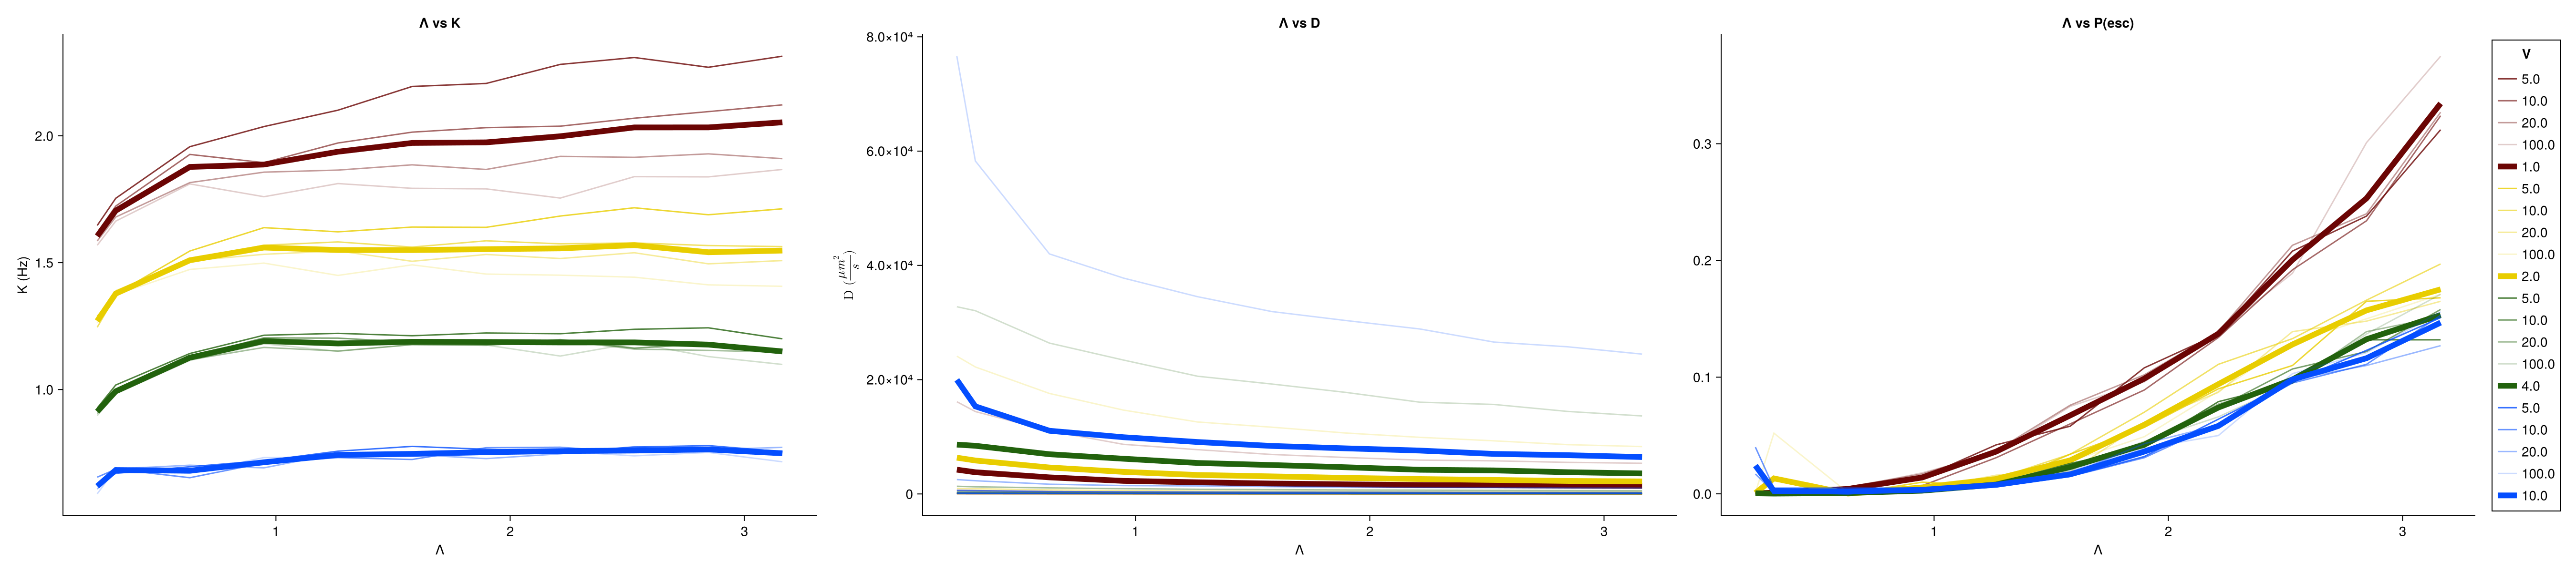

In [51]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766]
lambdas = [ 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (2700, 600))
ax_k = Axis(fig[1,1], title = "Λ vs K", xlabel = "Λ", ylabel = "K (Hz)")
ax_D = Axis(fig[1,2], title = "Λ vs D", xlabel = "Λ", ylabel = L"D ($\frac{\mu m^2}{s}$)")
ax_P = Axis(fig[1,3], title = "Λ vs P(esc)", xlabel = "Λ")
lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
intensity = [0.8, 0.6, 0.4, 0.2]


for (idx_t, tm) in enumerate(tms)
        mean_tms_k = zeros(4, 11)
        mean_tms_D = zeros(4, 11)
        mean_tms_P = zeros(4, 11)


    for (idx_v, v) in enumerate(vel)
        k_v = []
        D_v = []
        P_v = []


        for (idx_l, l) in enumerate(lambdas)
            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            k = row.k[1]
            D = row.D[1]
            P_esc = row.P_esc[1]

            push!(k_v, k)
            push!(D_v, D)
            push!(P_v, P_esc)
        end
       
        mean_tms_k[idx_v, :] = k_v
        mean_tms_D[idx_v, :] = D_v
        mean_tms_P[idx_v, :] = P_v

        

        lines!(ax_k, lambdas_x, k_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        lines!(ax_D, lambdas_x, D_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        lines!(ax_P, lambdas_x, P_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        
        

    end

    mean_k = []
    mean_D = []
    mean_P = []

    for i in 1:length(lambdas)
        push!(mean_k, mean(mean_tms_k[:, i]))
        push!(mean_D, mean(mean_tms_D[:, i]))
        push!(mean_P, mean(mean_tms_P[:, i]))
        
    end

    lines!(ax_k, lambdas_x, mean_k, linewidth = 6, label ="$tm", color = colors[idx_t])
    lines!(ax_D, lambdas_x, mean_D, linewidth = 6, label ="$tm", color = colors[idx_t])
    lines!(ax_P, lambdas_x, mean_P, linewidth = 6, label ="$tm", color = colors[idx_t])
end   

ax_k.topspinevisible = false
ax_k.rightspinevisible = false
ax_k.ygridvisible = false
ax_k.xgridvisible = false

ax_D.topspinevisible = false
ax_D.rightspinevisible = false
ax_D.ygridvisible = false
ax_D.xgridvisible = false

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

fig[1,4] = Legend(fig, ax_k, "V") # ?

fig            


In [52]:
save("Plots/Fixed_source_model/Next/All/metrics_all_K_D_P_075.pdf", fig)

CairoMakie.Screen{PDF}
